
# 01 — Diseño y simulación de escenarios de Loss Incurred

## Requisitos cubiertos

Este notebook desarrolla los primeros tres requisitos del proyecto:

1. **Definir tres escenarios mensuales acumulados de Loss Incurred**:
   - desarrollo creciente;
   - ajuste decreciente;
   - desarrollo mixto, con aumento temprano y disminución posterior.

2. **Elegir y documentar un horizonte de madurez `dev_M`** para cada escenario.

3. **Simular una base mensual para cada escenario**, incorporando:
   - tendencia;
   - estacionalidad;
   - variación aleatoria.

La lógica de simulación **no se implementa dentro del notebook**.  
Las funciones reutilizables viven en `src/simulation/`; aquí únicamente se:

- documenta la metodología;
- ejecutan las funciones;
- inspeccionan resultados;
- contrastan fórmulas con valores generados;
- visualizan las curvas y componentes de la simulación.

Esto permite que el notebook funcione como **documentación ejecutable** de la implementación.



## 1. Estructura conceptual de la simulación

Para cada período de ocurrencia $i$, primero se simula un nivel definitivo de pérdidas:

$$
Ultimate_i
=
Base
\times Trend_i
\times Seasonality_i
\times \varepsilon_i^{(occ)}.
$$

Después, para cada edad de desarrollo $j$, se aplica una curva acumulada de desarrollo $D_j$:

$$
E[LI_{i,j}]
=
Ultimate_i \times D_j.
$$

Finalmente, se incorpora variación específica de desarrollo:

$$
LI_{i,j}
=
Ultimate_i
\times D_j
\times \varepsilon_{i,j}^{(dev)}.
$$

Por tanto, la simulación separa explícitamente dos fuentes de variabilidad:

- **ruido de ocurrencia**: afecta el nivel definitivo del período completo;
- **ruido de desarrollo**: introduce pequeñas fluctuaciones entre edades de desarrollo.

La simulación completa sigue el flujo:

$$
\text{Base}
\rightarrow
Trend
\rightarrow
Seasonality
\rightarrow
\varepsilon^{(occ)}
\rightarrow
Ultimate
\rightarrow
D_j
\rightarrow
\varepsilon^{(dev)}
\rightarrow
Loss\ Incurred.
$$

Las funciones correspondientes se encuentran principalmente en:

- `src/simulation/components.py`
- `src/simulation/development.py`
- `src/simulation/generator.py`


In [1]:

# ============================================================
# IMPORTS Y CONFIGURACIÓN DEL ENTORNO
# ============================================================

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Permite importar src/ cuando el notebook se ejecuta desde notebooks/
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.simulation import (
    SCENARIO_CONFIGS,
    SimulationConfig,
    create_occurrence_table,
    simulate_all_scenarios,
)

from src.simulation.components import (
    trend_factor,
    seasonality_factor,
    lognormal_noise,
)

from src.simulation.development import (
    development_curve,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")



## 2. Configuración general

Los parámetros globales de simulación se concentran en `SimulationConfig`.

La configuración por defecto utiliza:

- períodos de ocurrencia entre **2015-01 y 2025-12**;
- `base_loss = 1,000,000`;
- tendencia anual de **4 %**;
- amplitud estacional de **8 %**;
- ruido de ocurrencia lognormal con $\sigma = 0.08$;
- ruido de desarrollo lognormal con $\sigma = 0.015$;
- semilla aleatoria fija para reproducibilidad.

Separar estos parámetros de la lógica permite cambiar las hipótesis del ejercicio sin modificar las funciones.


In [2]:

config = SimulationConfig()
config


SimulationConfig(start_period='2015-01', end_period='2025-12', base_loss=1000000.0, annual_trend=0.04, seasonality_amplitude=0.08, occurrence_noise_sigma=0.08, development_noise_sigma=0.015, random_seed=42)


## 3. Configuración de los escenarios y horizonte de madurez

Cada escenario tiene su propio patrón de desarrollo y un horizonte `dev_M`.

| Escenario | `dev_M` | Nivel inicial | Característica |
|---|---:|---:|---|
| Creciente | 60 meses | 0.55 | parte por debajo del definitivo y aumenta |
| Decreciente | 48 meses | 1.25 | parte por encima del definitivo y disminuye |
| Mixto | 48 meses | 0.65 | aumenta hasta un máximo y luego disminuye |

En el escenario mixto se utiliza además:

$$
peak\_month = 18,
\qquad
peak\_level = 1.15.
$$

El horizonte `dev_M` se interpreta como la edad a la que el desarrollo simulado alcanza su nivel definitivo:

$$
D_M = 1.
$$

Esta propiedad se impone directamente en las curvas definidas en `src/simulation/development.py`.


In [3]:

scenario_summary = pd.DataFrame(
    {
        name: {
            "dev_M": cfg.dev_M,
            "start_level": cfg.start_level,
            "peak_level": cfg.peak_level,
            "peak_month": cfg.peak_month,
            "description": cfg.description,
        }
        for name, cfg in SCENARIO_CONFIGS.items()
    }
).T

scenario_summary


,dev_M,start_level,peak_level,peak_month,description
creciente,60,0.5500,None,None,Desarrollo acumulado creciente. El Loss Incurr...
decreciente,48,1.2500,None,None,Desarrollo acumulado decreciente. El Loss Incu...
mixto,48,0.6500,1.1500,18,Desarrollo mixto. El Loss Incurred aumenta dur...



# 4. Simulación del nivel definitivo por período de ocurrencia

Antes de introducir el desarrollo, se genera un `ultimate_loss` para cada mes de ocurrencia.

La función responsable es:

```python
create_occurrence_table(...)
```

y utiliza tres componentes principales:

1. tendencia;
2. estacionalidad;
3. ruido de ocurrencia.

Primero analizamos cada componente por separado.



## 4.1 Tendencia

La tendencia se implementa mediante capitalización compuesta:

$$
Trend_t
=
(1+r)^{t/12},
$$

donde:

- $r$ es la tendencia anual;
- $t$ es el número de meses desde el inicio de la simulación.

Con $r=0.04$:

$$
Trend_0 = 1,
\qquad
Trend_{12} = 1.04.
$$

Esta fórmula corresponde directamente a `trend_factor()` en `components.py`.


In [4]:

months_example = np.array([0, 6, 12, 24, 60])

trend_example = pd.DataFrame({
    "month_index": months_example,
    "trend_factor": trend_factor(
        month_index=months_example,
        annual_trend=config.annual_trend,
    ),
})

trend_example


,month_index,trend_factor
0,0,1.0000
1,6,1.0198
2,12,1.0400
3,24,1.0816
4,60,1.2167



## 4.2 Estacionalidad

La estacionalidad mensual se modela con una función sinusoidal:

$$
S_m
=
1
+
A\sin\left(
\frac{2\pi(m-1)}{12}
\right),
$$

donde:

- $m\in\{1,\ldots,12\}$ representa el mes calendario;
- $A$ es la amplitud estacional.

Con `seasonality_amplitude = 0.08`, el factor oscila aproximadamente entre:

$$
0.92
\quad\text{y}\quad
1.08.
$$

La media anual permanece alrededor de 1, de modo que el componente introduce estacionalidad sin modificar sistemáticamente el nivel general.

Esta fórmula está implementada en `seasonality_factor()`.


In [5]:

periods_12m = pd.period_range("2020-01", "2020-12", freq="M")

seasonality_example = pd.DataFrame({
    "period": periods_12m.astype(str),
    "month": periods_12m.month,
    "seasonality_factor": seasonality_factor(
        periods=periods_12m,
        amplitude=config.seasonality_amplitude,
    ),
})

seasonality_example


,period,month,seasonality_factor
0,2020-01,1,1.0000
1,2020-02,2,1.0400
2,2020-03,3,1.0693
3,2020-04,4,1.0800
4,2020-05,5,1.0693
5,2020-06,6,1.0400
6,2020-07,7,1.0000
7,2020-08,8,0.9600
8,2020-09,9,0.9307
9,2020-10,10,0.9200


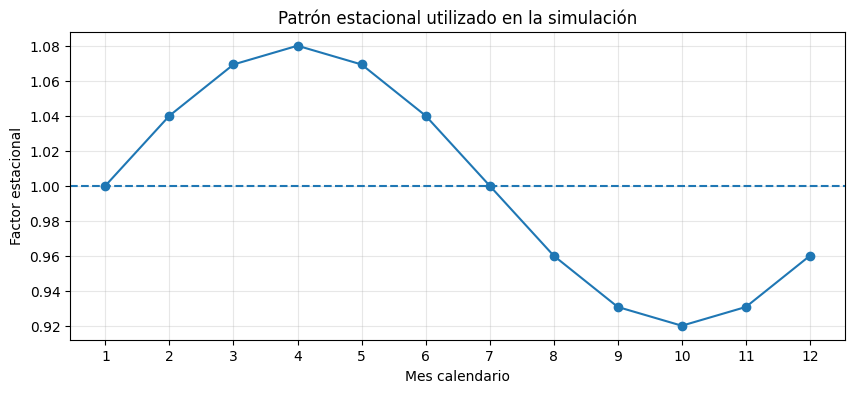

In [6]:

plt.figure(figsize=(10, 4))
plt.plot(
    seasonality_example["month"],
    seasonality_example["seasonality_factor"],
    marker="o",
)
plt.axhline(1.0, linestyle="--")
plt.xticks(range(1, 13))
plt.xlabel("Mes calendario")
plt.ylabel("Factor estacional")
plt.title("Patrón estacional utilizado en la simulación")
plt.grid(alpha=0.3)
plt.show()



## 4.3 Ruido lognormal

La variación aleatoria se modela mediante factores lognormales:

$$
\varepsilon
\sim
Lognormal\left(
-\frac{\sigma^2}{2},
\sigma
\right).
$$

Se utiliza:

$$
\mu=-\frac{\sigma^2}{2}
$$

porque entonces:

$$
E[\varepsilon]
=
e^{\mu+\sigma^2/2}
=
1.
$$

Esto es útil porque:

- el ruido es **siempre positivo**;
- la variación es multiplicativa;
- su esperanza está centrada alrededor de 1.

La función `lognormal_noise()` implementa esta distribución.

Existen dos valores de $\sigma$:

- `occurrence_noise_sigma`: variación entre períodos de ocurrencia;
- `development_noise_sigma`: pequeñas fluctuaciones dentro de la trayectoria de desarrollo.


In [7]:

rng_demo = np.random.default_rng(config.random_seed)

noise_demo = lognormal_noise(
    size=100_000,
    sigma=config.occurrence_noise_sigma,
    rng=rng_demo,
)

pd.Series(noise_demo).describe()


count   100,000.0000
mean          0.9997
std           0.0804
min           0.7016
25%           0.9441
50%           0.9961
75%           1.0517
max           1.4879
dtype: float64

In [8]:

print(f"Mínimo: {noise_demo.min():.4f}")
print(f"Media simulada: {noise_demo.mean():.4f}")
print(f"Máximo: {noise_demo.max():.4f}")
print(f"Todos positivos: {(noise_demo > 0).all()}")


Mínimo: 0.7016
Media simulada: 0.9997
Máximo: 1.4879
Todos positivos: True



## 4.4 Construcción de `ultimate_loss`

La función `create_occurrence_table()` combina los componentes anteriores.

Primero calcula:

$$
\text{Expected Ultimate}_i
=
Base
\times Trend_i
\times Seasonality_i.
$$

Posteriormente incorpora ruido:

$$
Ultimate_i
=
\text{Expected Ultimate}_i
\times \varepsilon_i^{(occ)}.
$$

El resultado es una tabla con una fila por período de ocurrencia.


In [9]:

rng_occurrence = np.random.default_rng(config.random_seed)

occurrence_table = create_occurrence_table(
    config=config,
    rng=rng_occurrence,
)

occurrence_table.head()


,accident_period,month_index,trend_factor,seasonality_factor,occurrence_noise,expected_ultimate,ultimate_loss
0,2015-01,0,1.0000,1.0000,1.0214,"1,000,000.0000","1,021,403.1982"
1,2015-02,1,1.0033,1.0400,0.9172,"1,043,404.6894","957,040.4484"
2,2015-03,2,1.0066,1.0693,1.0585,"1,076,294.5945","1,139,238.7846"
3,2015-04,3,1.0099,1.0800,1.0747,"1,090,641.6791","1,172,116.8608"
4,2015-05,4,1.0132,1.0693,0.8528,"1,083,353.1464","923,834.9779"



### Comprobación manual de la fórmula

Tomamos la primera observación y reconstruimos `expected_ultimate` y `ultimate_loss` utilizando exclusivamente sus componentes.

Si la implementación coincide con la metodología, las diferencias deben ser prácticamente cero.


In [10]:

row = occurrence_table.iloc[0]

expected_ultimate_manual = (
    config.base_loss
    * row["trend_factor"]
    * row["seasonality_factor"]
)

ultimate_manual = (
    expected_ultimate_manual
    * row["occurrence_noise"]
)

manual_check_occurrence = pd.Series({
    "expected_ultimate_src": row["expected_ultimate"],
    "expected_ultimate_manual": expected_ultimate_manual,
    "difference_expected": row["expected_ultimate"] - expected_ultimate_manual,
    "ultimate_loss_src": row["ultimate_loss"],
    "ultimate_loss_manual": ultimate_manual,
    "difference_ultimate": row["ultimate_loss"] - ultimate_manual,
})

manual_check_occurrence


expected_ultimate_src      1,000,000.0000
expected_ultimate_manual   1,000,000.0000
difference_expected                0.0000
ultimate_loss_src          1,021,403.1982
ultimate_loss_manual       1,021,403.1982
difference_ultimate                0.0000
dtype: float64

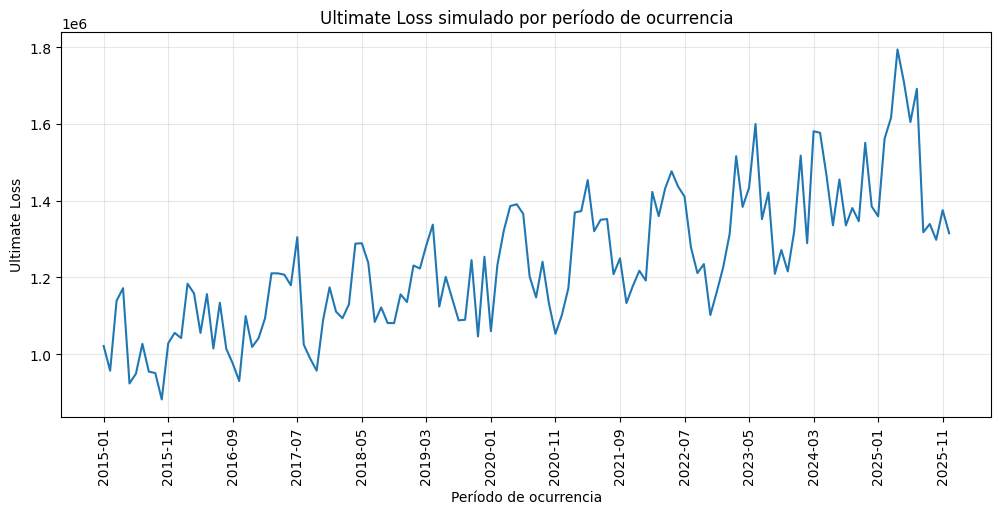

In [11]:

plt.figure(figsize=(12, 5))
plt.plot(
    occurrence_table["accident_period"].astype(str),
    occurrence_table["ultimate_loss"],
)
plt.xlabel("Período de ocurrencia")
plt.ylabel("Ultimate Loss")
plt.title("Ultimate Loss simulado por período de ocurrencia")
plt.xticks(rotation=90)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(15))
plt.grid(alpha=0.3)
plt.show()



# 5. Curvas de desarrollo

Una vez generado el `ultimate_loss`, se modela cómo evoluciona el Loss Incurred acumulado con la edad de desarrollo.

La función general es:

```python
development_curve(dev_month, scenario)
```

que redirige internamente hacia una de tres funciones:

- `increasing_curve()`
- `decreasing_curve()`
- `mixed_curve()`

El valor devuelto es el factor acumulado $D_j$.

Por definición:

$$
E[LI_{i,j}]
=
Ultimate_i \times D_j.
$$

A continuación se documenta exactamente cómo se construye cada curva.



## 5.1 Escenario creciente

El escenario creciente parte de un nivel inferior a 1 y converge suavemente hacia la madurez.

La función utiliza:

$$
x = \frac{j}{M}
$$

y una transformación exponencial:

$$
R(x)
=
1-e^{-kx},
$$

con `speed = k = 3`.

Como $R(1)\neq1$, primero se normaliza:

$$
R^*(x)
=
\frac{1-e^{-kx}}
{1-e^{-k}}.
$$

Finalmente:

$$
D_j
=
start
+
(1-start)R^*(x).
$$

Por construcción:

$$
D_0=start
$$

y

$$
D_M=1.
$$

Con `start_level = 0.55`, la trayectoria comienza reconociendo aproximadamente 55 % del nivel definitivo y después aumenta de forma monotónica.



## 5.2 Escenario decreciente

En este caso el Loss Incurred parte **por encima** del definitivo y se ajusta gradualmente hacia abajo.

De nuevo:

$$
x=\frac{j}{M}.
$$

Se utiliza:

$$
R(x)=e^{-kx}
$$

y se normaliza para que el valor en $M$ sea exactamente 1:

$$
R^*(x)
=
\frac{e^{-kx}-e^{-k}}
{1-e^{-k}}.
$$

La curva final es:

$$
D_j
=
1
+
(start-1)R^*(x).
$$

Con `start_level = 1.25`:

$$
D_0=1.25,
\qquad
D_M=1.
$$

Esto representa un escenario con estimaciones iniciales superiores al nivel definitivo y liberaciones posteriores.



## 5.3 Escenario mixto

El escenario mixto se construye en dos etapas:

1. crecimiento desde `start_level` hasta `peak_level`;
2. disminución desde `peak_level` hasta 1.

Para suavizar ambas transiciones se utiliza la función **smoothstep**:

$$
s(x)=3x^2-2x^3.
$$

### Etapa temprana

Para:

$$
0\le j\le peak\_month,
$$

se define:

$$
x_{early}
=
\frac{j}{peak\_month},
$$

y:

$$
D_j
=
start
+
(peak-start)s(x_{early}).
$$

### Etapa tardía

Para:

$$
peak\_month<j\le M,
$$

se define:

$$
x_{late}
=
\frac{j-peak\_month}
{M-peak\_month},
$$

y:

$$
D_j
=
peak
+
(1-peak)s(x_{late}).
$$

Con la configuración actual:

$$
start=0.65,
\qquad
peak=1.15,
\qquad
peak\_month=18,
\qquad
M=48.
$$

Así, la curva aumenta inicialmente, supera el nivel definitivo alrededor del mes 18 y después disminuye hasta 1.


In [12]:

development_tables = {}

for scenario_name, scenario in SCENARIO_CONFIGS.items():
    dev_month = np.arange(scenario.dev_M + 1)

    curve = development_curve(
        dev_month=dev_month,
        scenario=scenario,
    )

    development_tables[scenario_name] = pd.DataFrame({
        "scenario": scenario_name,
        "dev_month": dev_month,
        "development_factor": curve,
    })

development_df = pd.concat(
    development_tables.values(),
    ignore_index=True,
)

development_df.head()


,scenario,dev_month,development_factor
0,creciente,0,0.5500
1,creciente,1,0.5731
2,creciente,2,0.5951
3,creciente,3,0.6160
4,creciente,4,0.6358


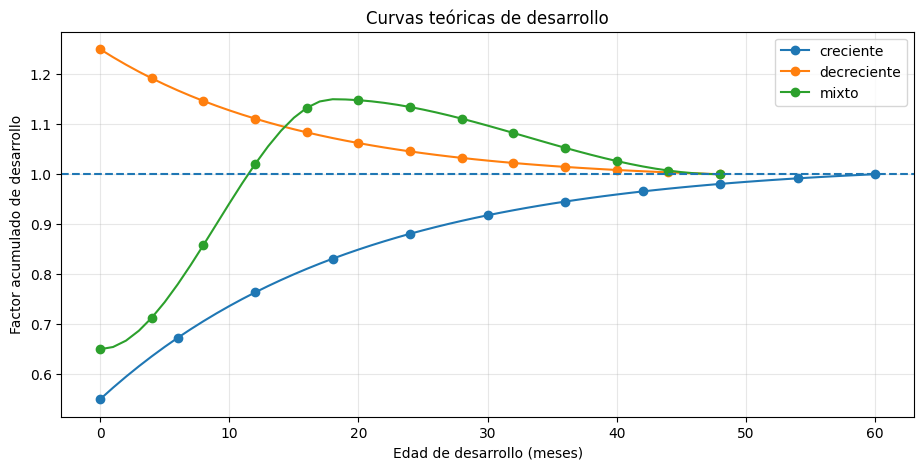

In [13]:

plt.figure(figsize=(11, 5))

for scenario_name, group in development_df.groupby("scenario"):
    plt.plot(
        group["dev_month"],
        group["development_factor"],
        marker="o",
        markevery=max(len(group) // 10, 1),
        label=scenario_name,
    )

plt.axhline(1.0, linestyle="--")
plt.xlabel("Edad de desarrollo (meses)")
plt.ylabel("Factor acumulado de desarrollo")
plt.title("Curvas teóricas de desarrollo")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



### Comprobaciones de comportamiento

Las pruebas unitarias del proyecto ya verifican estas propiedades, pero aquí se muestran también de forma descriptiva:

- creciente:
  $$
  D_0<D_1<\cdots<D_{60}=1;
  $$
- decreciente:
  $$
  D_0>D_1>\cdots>D_{48}=1;
  $$
- mixto:
  $$
  D_0<\cdots<D_{18}>\cdots>D_{48}=1.
  $$
  
Es importante diferenciar entre:

- `development_factor`: patrón teórico diseñado;
- `loss_incurred`: observación simulada con ruido.

Por ello, la monotonicidad estricta se exige a la **curva teórica**, no necesariamente a cada trayectoria observada de `loss_incurred`.


In [14]:

curve_checks = []

for scenario_name, table in development_tables.items():
    factor = table["development_factor"].to_numpy()
    scenario = SCENARIO_CONFIGS[scenario_name]

    if scenario_name == "creciente":
        expected_pattern = np.all(np.diff(factor) > 0)
    elif scenario_name == "decreciente":
        expected_pattern = np.all(np.diff(factor) < 0)
    else:
        peak = scenario.peak_month
        expected_pattern = (
            np.all(np.diff(factor[: peak + 1]) > 0)
            and np.all(np.diff(factor[peak:]) < 0)
        )

    curve_checks.append({
        "scenario": scenario_name,
        "start_factor": factor[0],
        "end_factor": factor[-1],
        "expected_pattern": expected_pattern,
    })

pd.DataFrame(curve_checks)


,scenario,start_factor,end_factor,expected_pattern
0,creciente,0.5500,1.0000,True
1,decreciente,1.2500,1.0000,True
2,mixto,0.6500,1.0000,True



# 6. Generación de las tres bases maestras

La función:

```python
simulate_all_scenarios(config)
```

genera un diccionario con:

- `creciente`;
- `decreciente`;
- `mixto`.

Cada base se almacena en formato longitudinal:

$$
accident\_period
\times
dev\_month.
$$

Para cada período de ocurrencia se genera la trayectoria completa desde:

$$
dev\_month=0
$$

hasta:

$$
dev\_month=dev_M.
$$

Por ejemplo, para el escenario creciente existen $61$ observaciones por período:

$$
0,1,\ldots,60.
$$

Esto significa que también se generan valores cuyo `calendar_period` es posterior al último mes de ocurrencia.

**Esto es intencional.**

La base maestra representa la **verdad completa simulada**. Más adelante, una valuación histórica se construirá mediante:

```python
calendar_period <= valuation_period
```

De esta forma se separa claramente:

- la trayectoria real simulada;
- la información disponible en una fecha de valuación.

Esta separación será fundamental para el backtesting sin fuga de información.


In [15]:

simulations = simulate_all_scenarios(config)

list(simulations.keys())


['creciente', 'decreciente', 'mixto']

In [16]:

simulation_summary = []

for scenario_name, df in simulations.items():
    simulation_summary.append({
        "scenario": scenario_name,
        "rows": len(df),
        "accident_periods": df["accident_period"].nunique(),
        "dev_min": df["dev_month"].min(),
        "dev_max": df["dev_month"].max(),
        "calendar_min": str(df["calendar_period"].min()),
        "calendar_max": str(df["calendar_period"].max()),
    })

pd.DataFrame(simulation_summary)


,scenario,rows,accident_periods,dev_min,dev_max,calendar_min,calendar_max
0,creciente,8052,132,0,60,2015-01,2030-12
1,decreciente,6468,132,0,48,2015-01,2029-12
2,mixto,6468,132,0,48,2015-01,2029-12



## 6.1 Estructura de una base simulada

Las columnas principales son:

- `scenario`: escenario simulado;
- `accident_period`: período de ocurrencia;
- `dev_month`: edad de desarrollo;
- `calendar_period`: período calendario observado;
- `dev_M`: horizonte de madurez;
- `trend_factor`: tendencia;
- `seasonality_factor`: estacionalidad;
- `occurrence_noise`: ruido asociado al período;
- `expected_ultimate`: ultimate esperado antes del ruido de ocurrencia;
- `ultimate_loss`: ultimate simulado;
- `development_factor`: curva teórica acumulada;
- `development_noise`: variación específica de la celda;
- `expected_loss_incurred`: Loss Incurred esperado;
- `loss_incurred`: observación final simulada.

La identidad temporal es:

$$
calendar\_period
=
accident\_period
+
dev\_month.
$$


In [17]:

simulations["creciente"].head(10)


,scenario,accident_period,dev_month,calendar_period,dev_M,month_index,trend_factor,seasonality_factor,occurrence_noise,expected_ultimate,ultimate_loss,development_factor,development_noise,expected_loss_incurred,loss_incurred
0,creciente,2015-01,0,2015-01,60,0,1.0000,1.0000,1.0214,"1,000,000.0000","1,021,403.1982",0.5500,1.0095,"561,771.7590","567,085.6831"
1,creciente,2015-01,1,2015-02,60,0,1.0000,1.0000,1.0214,"1,000,000.0000","1,021,403.1982",0.5731,0.9966,"585,362.7764","583,349.1809"
2,creciente,2015-01,2,2015-03,60,0,1.0000,1.0000,1.0214,"1,000,000.0000","1,021,403.1982",0.5951,0.9781,"607,803.2463","594,473.7897"
3,creciente,2015-01,3,2015-04,60,0,1.0000,1.0000,1.0214,"1,000,000.0000","1,021,403.1982",0.6160,0.9848,"629,149.2816","619,567.9461"
4,creciente,2015-01,4,2015-05,60,0,1.0000,1.0000,1.0214,"1,000,000.0000","1,021,403.1982",0.6358,1.0046,"649,454.2584","652,442.2409"
5,creciente,2015-01,5,2015-06,60,0,1.0000,1.0000,1.0214,"1,000,000.0000","1,021,403.1982",0.6548,1.0125,"668,768.9499","677,153.5337"
6,creciente,2015-01,6,2015-07,60,0,1.0000,1.0000,1.0214,"1,000,000.0000","1,021,403.1982",0.6727,1.0303,"687,141.6527","707,953.8618"
7,creciente,2015-01,7,2015-08,60,0,1.0000,1.0000,1.0214,"1,000,000.0000","1,021,403.1982",0.6899,1.0446,"704,618.3082","736,015.8740"
8,creciente,2015-01,8,2015-09,60,0,1.0000,1.0000,1.0214,"1,000,000.0000","1,021,403.1982",0.7061,1.0061,"721,242.6172","725,658.2857"
9,creciente,2015-01,9,2015-10,60,0,1.0000,1.0000,1.0214,"1,000,000.0000","1,021,403.1982",0.7216,0.9852,"737,056.1491","726,115.0719"



# 7. Comprobación completa de una observación

Para corroborar que `simulate_scenario()` implementa exactamente la metodología descrita, seleccionamos una observación y reconstruimos sus cálculos manualmente.

Primero:

$$
\text{Expected Ultimate}_i
=
Base
\times Trend_i
\times Seasonality_i.
$$

Luego:

$$
Ultimate_i
=
\text{Expected Ultimate}_i
\times \varepsilon_i^{(occ)}.
$$

Después:

$$
ExpectedLI_{i,j}
=
Ultimate_i
\times D_j.
$$

Finalmente:

$$
LI_{i,j}
=
ExpectedLI_{i,j}
\times
\varepsilon_{i,j}^{(dev)}.
$$


In [18]:

example_scenario = "mixto"
example_accident_period = pd.Period("2020-01", freq="M")
example_dev_month = 18

example_df = simulations[example_scenario]

example_row = example_df.loc[
    (example_df["accident_period"] == example_accident_period)
    & (example_df["dev_month"] == example_dev_month)
].iloc[0]

expected_ultimate_manual = (
    config.base_loss
    * example_row["trend_factor"]
    * example_row["seasonality_factor"]
)

ultimate_manual = (
    expected_ultimate_manual
    * example_row["occurrence_noise"]
)

expected_li_manual = (
    ultimate_manual
    * example_row["development_factor"]
)

loss_incurred_manual = (
    expected_li_manual
    * example_row["development_noise"]
)

manual_check = pd.DataFrame({
    "src": [
        example_row["expected_ultimate"],
        example_row["ultimate_loss"],
        example_row["expected_loss_incurred"],
        example_row["loss_incurred"],
    ],
    "manual": [
        expected_ultimate_manual,
        ultimate_manual,
        expected_li_manual,
        loss_incurred_manual,
    ],
}, index=[
    "expected_ultimate",
    "ultimate_loss",
    "expected_loss_incurred",
    "loss_incurred",
])

manual_check["difference"] = (
    manual_check["src"] - manual_check["manual"]
)

manual_check


,src,manual,difference
expected_ultimate,"1,216,652.9024","1,216,652.9024",0.0000
ultimate_loss,"1,424,082.7272","1,424,082.7272",0.0000
expected_loss_incurred,"1,637,695.1363","1,637,695.1363",0.0000
loss_incurred,"1,594,481.6228","1,594,481.6228",0.0000



# 8. Trayectoria completa de un período de ocurrencia

Ahora observamos un mismo período de ocurrencia a través de todas sus edades de desarrollo.

Esto permite distinguir visualmente:

- la curva teórica `development_factor`;
- el Loss Incurred esperado;
- el Loss Incurred observado con ruido.

En particular, el ruido de desarrollo puede introducir pequeñas oscilaciones en `loss_incurred`, aunque la curva teórica mantenga la dirección esperada.


In [19]:

example_period = pd.Period("2020-01", freq="M")

fig_data = []

for scenario_name, df in simulations.items():
    temp = df.loc[
        df["accident_period"] == example_period,
        [
            "scenario",
            "dev_month",
            "expected_loss_incurred",
            "loss_incurred",
            "ultimate_loss",
        ],
    ].copy()

    fig_data.append(temp)

trajectory_df = pd.concat(fig_data, ignore_index=True)

trajectory_df.head()


,scenario,dev_month,expected_loss_incurred,loss_incurred,ultimate_loss
0,creciente,0,"583,002.9593","579,669.3907","1,060,005.3805"
1,creciente,1,"607,485.5587","614,033.1574","1,060,005.3805"
2,creciente,2,"630,774.1277","616,882.2696","1,060,005.3805"
3,creciente,3,"652,926.8998","651,178.7530","1,060,005.3805"
4,creciente,4,"673,999.2684","657,353.9255","1,060,005.3805"


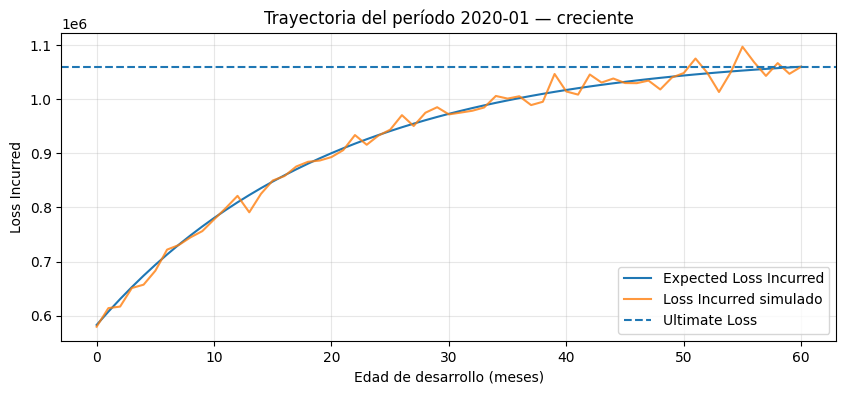

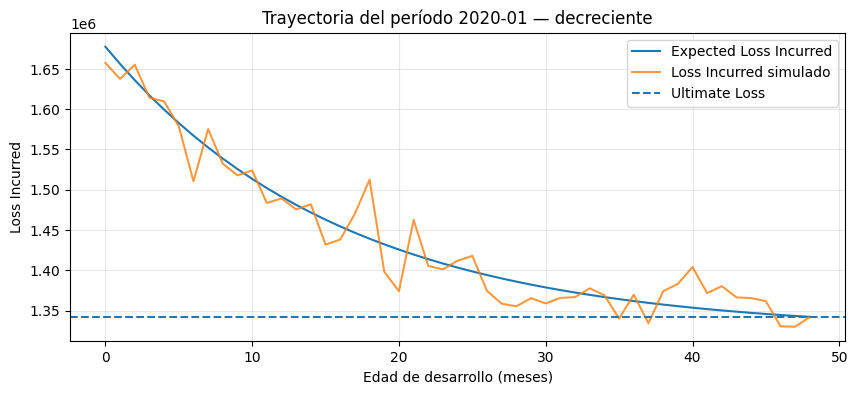

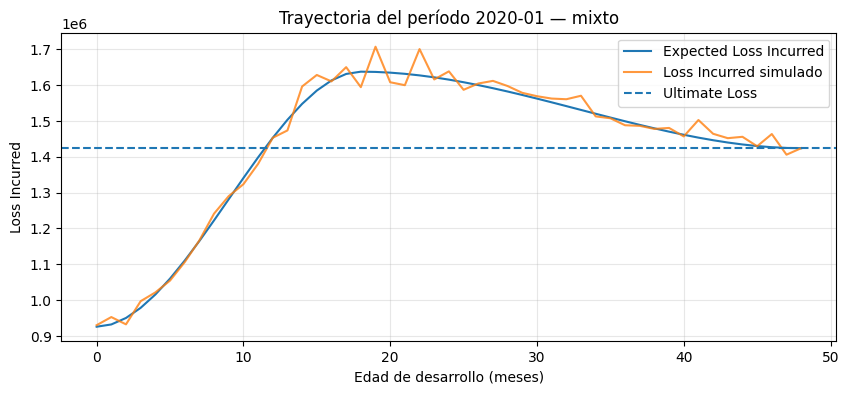

In [20]:

for scenario_name, group in trajectory_df.groupby("scenario"):
    plt.figure(figsize=(10, 4))

    plt.plot(
        group["dev_month"],
        group["expected_loss_incurred"],
        label="Expected Loss Incurred",
    )

    plt.plot(
        group["dev_month"],
        group["loss_incurred"],
        label="Loss Incurred simulado",
        alpha=0.8,
    )

    plt.axhline(
        group["ultimate_loss"].iloc[0],
        linestyle="--",
        label="Ultimate Loss",
    )

    plt.xlabel("Edad de desarrollo (meses)")
    plt.ylabel("Loss Incurred")
    plt.title(
        f"Trayectoria del período {example_period} — {scenario_name}"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()



# 9. Comprobación de la madurez

En la edad `dev_M` se imponen dos condiciones:

$$
D_M = 1
$$

y:

$$
\varepsilon^{(dev)}_{i,M}=1.
$$

Por tanto:

$$
LI_{i,M}
=
Ultimate_i.
$$

Esta condición es importante porque fija un punto definitivo común para interpretar las tres trayectorias.

El ruido de desarrollo se utiliza en edades anteriores, pero se elimina exactamente en la madurez para preservar esta identidad.


In [21]:

maturity_checks = []

for scenario_name, df in simulations.items():
    dev_M = SCENARIO_CONFIGS[scenario_name].dev_M

    mature = df.loc[df["dev_month"] == dev_M].copy()

    maturity_checks.append({
        "scenario": scenario_name,
        "n_mature": len(mature),
        "max_abs_diff_factor_vs_1": (
            mature["development_factor"] - 1.0
        ).abs().max(),
        "max_abs_diff_noise_vs_1": (
            mature["development_noise"] - 1.0
        ).abs().max(),
        "max_abs_diff_loss_vs_ultimate": (
            mature["loss_incurred"]
            - mature["ultimate_loss"]
        ).abs().max(),
    })

pd.DataFrame(maturity_checks)


,scenario,n_mature,max_abs_diff_factor_vs_1,max_abs_diff_noise_vs_1,max_abs_diff_loss_vs_ultimate
0,creciente,132,0.0000,0.0000,0.0000
1,decreciente,132,0.0000,0.0000,0.0000
2,mixto,132,0.0000,0.0000,0.0000



# 10. Reproducibilidad

La simulación utiliza `numpy.random.Generator` con una semilla fija.

Además, cada escenario utiliza un desplazamiento distinto sobre la semilla base:

- creciente: `seed + 0`;
- decreciente: `seed + 1`;
- mixto: `seed + 2`.

Esto permite que:

1. cada escenario tenga realizaciones aleatorias distintas;
2. ejecutar nuevamente el proyecto con la misma configuración produzca exactamente los mismos datos.

La reproducibilidad también está cubierta por las pruebas unitarias de `tests/test_simulation.py`.


In [22]:

simulations_repeated = simulate_all_scenarios(config)

reproducibility_check = {
    scenario_name: simulations[scenario_name].equals(
        simulations_repeated[scenario_name]
    )
    for scenario_name in simulations
}

reproducibility_check


{'creciente': True, 'decreciente': True, 'mixto': True}


# 11. Resumen de los requisitos 1–3

Con este notebook quedan implementados y documentados los tres primeros requisitos.

## Requisito 1 — Tres escenarios de Loss Incurred

Se definieron:

### Creciente

$$
D_0 < \cdots < D_{60}=1.
$$

Representa reconocimiento gradual de pérdidas desde un nivel inicial inferior al definitivo.

### Decreciente

$$
D_0 > \cdots > D_{48}=1.
$$

Representa ajustes posteriores desde un nivel inicialmente superior al definitivo.

### Mixto

$$
D_0 < \cdots < D_{18}
>
\cdots
>
D_{48}=1.
$$

Representa crecimiento temprano seguido de disminución posterior.

---

## Requisito 2 — Horizonte de madurez

Se establecieron:

- creciente: `dev_M = 60`;
- decreciente: `dev_M = 48`;
- mixto: `dev_M = 48`.

En todos los casos:

$$
D_M=1.
$$

---

## Requisito 3 — Simulación mensual

El nivel definitivo por período de ocurrencia incorpora:

$$
Ultimate_i
=
Base
\times Trend_i
\times Seasonality_i
\times \varepsilon_i^{(occ)}.
$$

Mientras que el desarrollo observado utiliza:

$$
LI_{i,j}
=
Ultimate_i
\times D_j
\times \varepsilon_{i,j}^{(dev)}.
$$

Por tanto, las bases simuladas contienen explícitamente:

- tendencia;
- estacionalidad;
- variación aleatoria;
- patrón de desarrollo;
- períodos de ocurrencia;
- edades de desarrollo;
- períodos calendario.

---


## 12. Exportación opcional de las bases simuladas

La simulación puede regenerarse en cualquier momento a partir de `src/`, por lo que guardar CSV no es estrictamente necesario.

Sin embargo, si se desea conservar una versión concreta de las bases para las siguientes etapas, puede utilizarse la siguiente celda.

Se recomienda versionar el **código y la configuración**, no necesariamente los archivos simulados si estos pueden regenerarse de forma determinista.


In [23]:

# Descomentar únicamente si se desea persistir las bases.
#
# output_dir = PROJECT_ROOT / "data" / "simulated"
# output_dir.mkdir(parents=True, exist_ok=True)
#
# for scenario_name, df in simulations.items():
#     export_df = df.copy()
#
#     # Period no tiene una representación CSV estándar.
#     export_df["accident_period"] = export_df["accident_period"].astype(str)
#     export_df["calendar_period"] = export_df["calendar_period"].astype(str)
#
#     export_df.to_csv(
#         output_dir / f"loss_incurred_{scenario_name}.csv",
#         index=False,
#     )
